<a href="https://colab.research.google.com/github/fathimaa-afreen/ADD_ON_COURSE/blob/main/day_4_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile("/content/FACE.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/FACE",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=8
)


Found 40 files belonging to 4 classes.
Using 32 files for training.


In [ ]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/FACE",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=8
)


Found 40 files belonging to 4 classes.
Using 8 files for validation.


In [ ]:
class_names = train_dataset.class_names

print(class_names)

model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,input_shape=(128,128,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(4,activation="softmax")

])


['angry', 'sad', 'smile', 'tension']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.2812 - loss: 1.9639 - val_accuracy: 0.2500 - val_loss: 1.4394
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.2500 - loss: 1.4119 - val_accuracy: 0.3750 - val_loss: 1.3880
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.3125 - loss: 1.3806 - val_accuracy: 0.1250 - val_loss: 1.4067
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - accuracy: 0.3125 - loss: 1.3643 - val_accuracy: 0.1250 - val_loss: 1.4325
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - accuracy: 0.6562 - loss: 1.2065 - val_accuracy: 0.5000 - val_loss: 1.3880
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.6250 - loss: 1.0691 - val_accuracy: 0.2500 - val_loss: 1.6821
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.6875 - loss: 0.8663 - val_accuracy: 0.3750 - val_loss: 1.6749
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.8125 - loss: 0.5806 - val_accuracy: 0.2500 - val_loss:

In [ ]:
model.save("emotion_model.keras")

print("Model Saved")


Model Saved


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving smilleee.jpg to smilleee.jpg


In [ ]:
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array/255.0

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)*100


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


In [ ]:
print("Predicted Emotion :", predicted_class)
print("Confidence :", round(confidence,2),"%")



Predicted Emotion : smile
Confidence : 37.3 %


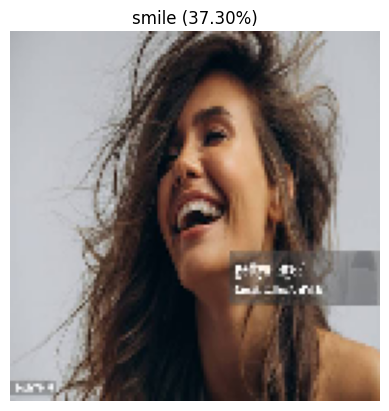

In [ ]:
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()